# Phase 1 — Exploratory Data Analysis
**AgroSense AI Pipeline**

Dataset: `Crop_recommendation.csv` — 2200 rows, 7 features, 22 crop classes

Goals:
- Understand feature distributions
- Identify outliers
- Visualise class balance
- Analyse feature correlations
- Save processed data for Phase 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120,
})
PALETTE = '#2E7D32'
print('Libraries loaded.')

Libraries loaded.


## 1.1  Load Dataset

In [4]:
df = pd.read_csv('Crop_recommendation.csv')
df.columns = df.columns.str.strip().str.lower()

# Normalise label column
for col in ['label','crop','class']:
    if col in df.columns:
        df.rename(columns={col: 'label'}, inplace=True)
        break

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2200, 8)
Columns: ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
print('=== Basic Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicates ===')
print(df.duplicated().sum())

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   n            2200 non-null   int64  
 1   p            2200 non-null   int64  
 2   k            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

=== Missing Values ===
n              0
p              0
k              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Duplicates ===
0


## 1.2  Descriptive Statistics

In [6]:
FEATURES = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
df[FEATURES].describe().round(2)

,n,p,k,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


## 1.3  Class Distribution

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/phase1_class_distribution.png'

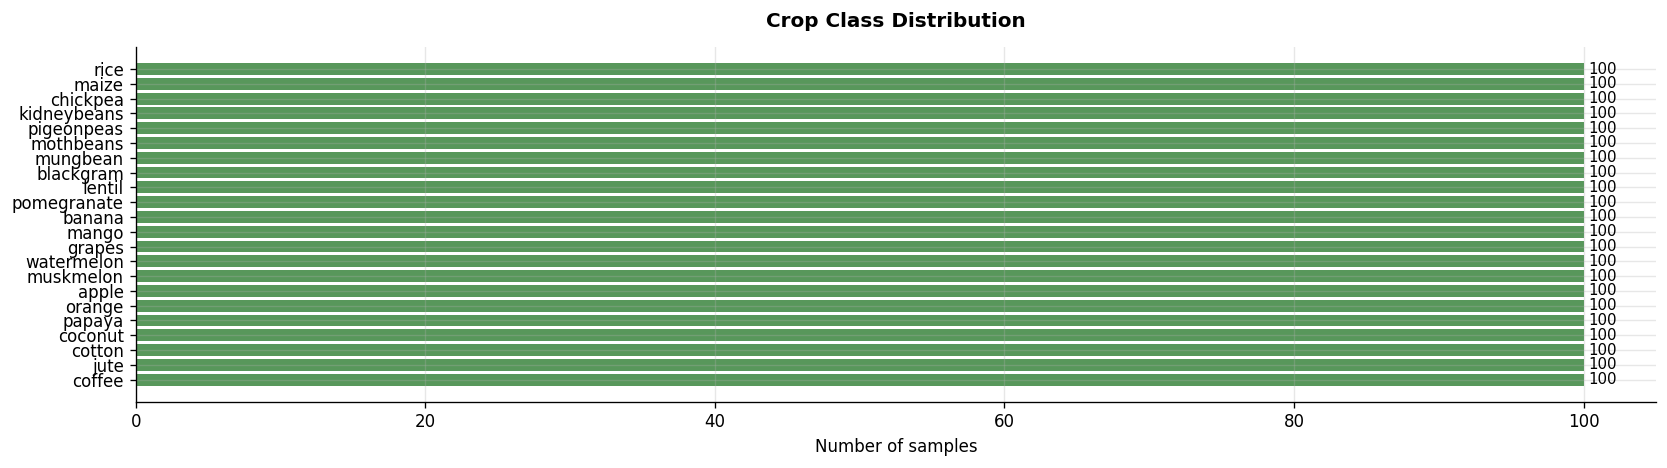

In [7]:
counts = df['label'].value_counts()

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.barh(counts.index[::-1], counts.values[::-1], color='#2E7D32', alpha=0.8)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of samples')
ax.set_title('Crop Class Distribution', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/phase1_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'Total classes: {df["label"].nunique()}')
print(f'Samples per class: min={counts.min()}, max={counts.max()}, mean={counts.mean():.0f}')

## 1.4  Feature Distributions

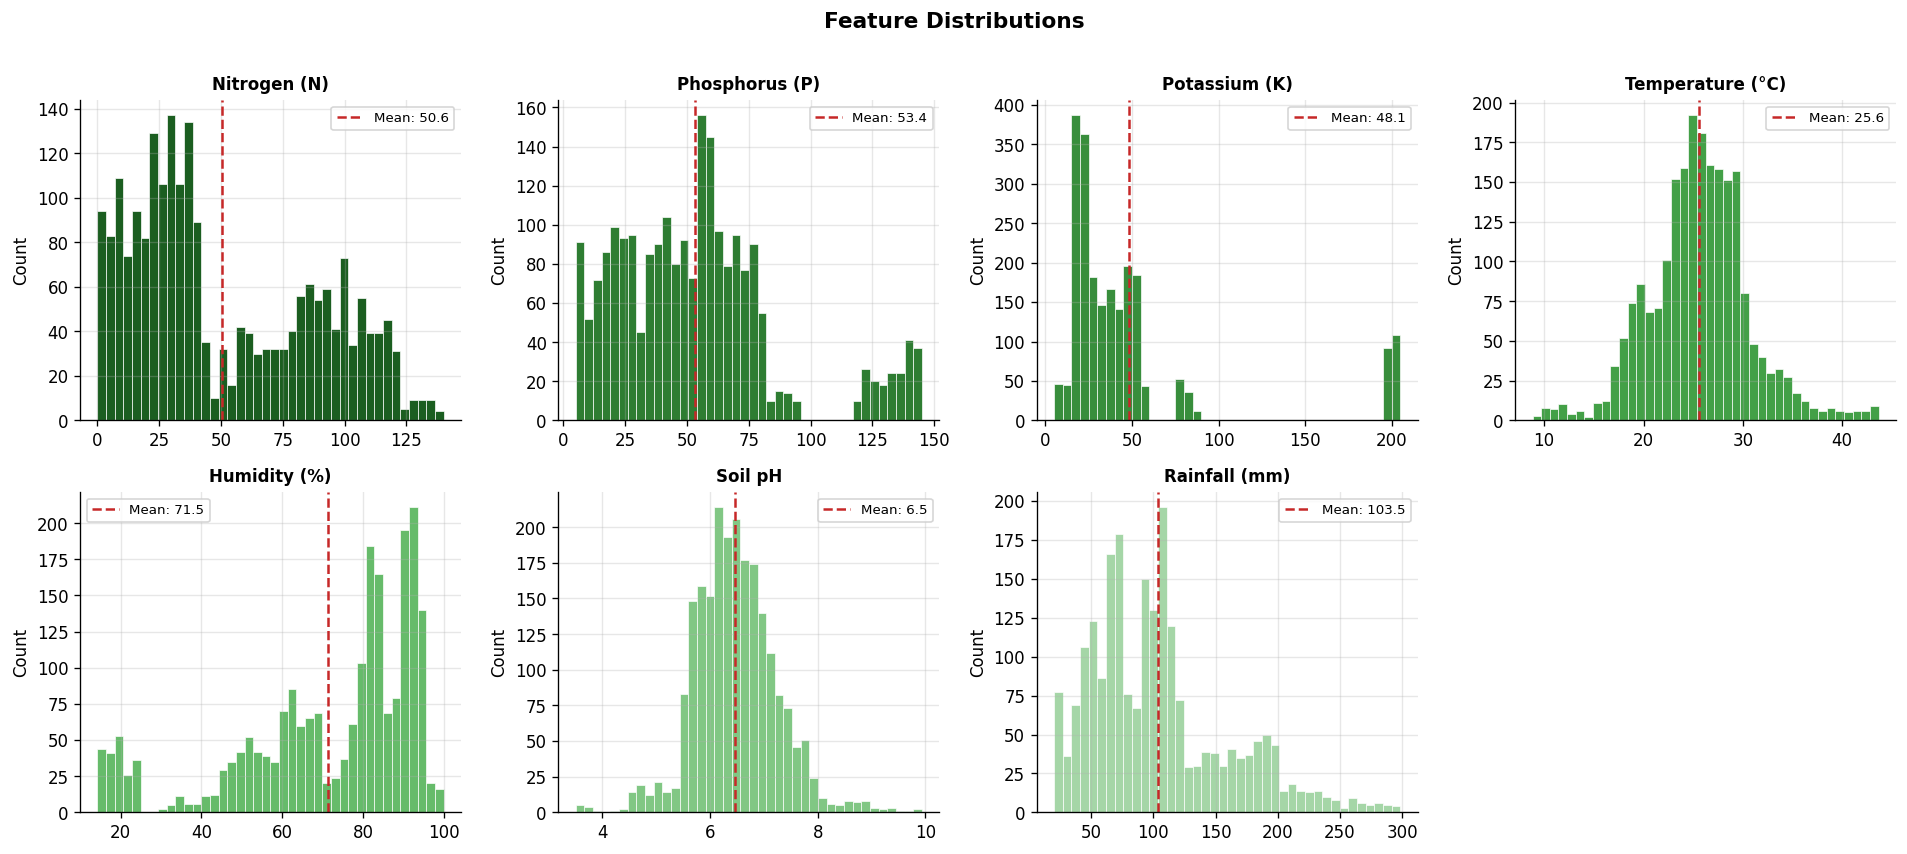

In [8]:
import os; os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = ['#1B5E20','#2E7D32','#388E3C','#43A047','#66BB6A','#81C784','#A5D6A7']
labels_map = {'n':'Nitrogen (N)','p':'Phosphorus (P)','k':'Potassium (K)',
              'temperature':'Temperature (°C)','humidity':'Humidity (%)',
              'ph':'Soil pH','rainfall':'Rainfall (mm)'}

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat], bins=40, color=colors[i], edgecolor='white', linewidth=0.4)
    axes[i].set_title(labels_map[feat], fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Count')
    mean_val = df[feat].mean()
    axes[i].axvline(mean_val, color='#C62828', linewidth=1.5, linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Feature Distributions', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase1_distributions.png', bbox_inches='tight')
plt.show()

## 1.5  Correlation Matrix

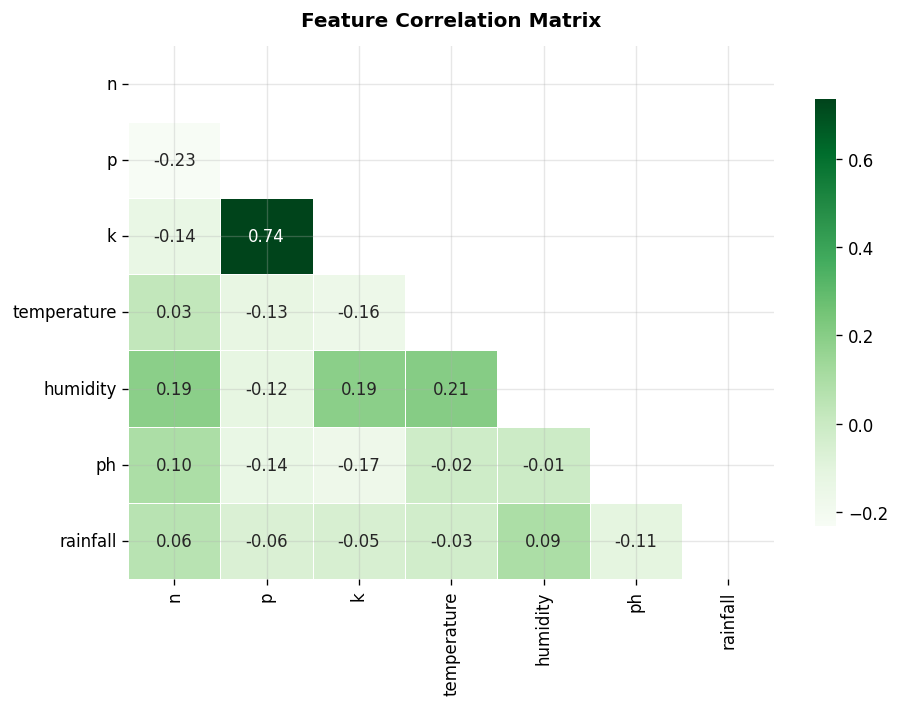

Strong correlations (|r| > 0.3):
  k vs p: 0.736


In [9]:
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/phase1_correlation.png', bbox_inches='tight')
plt.show()

# Highlight strong correlations
upper = corr.where(mask == False)
strong = [(r, c, upper.loc[r, c]) for r in upper.index for c in upper.columns
          if pd.notna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.3]
print('Strong correlations (|r| > 0.3):')
for r, c, v in strong:
    print(f'  {r} vs {c}: {v:.3f}')

## 1.6  Outlier Detection (IQR Method)

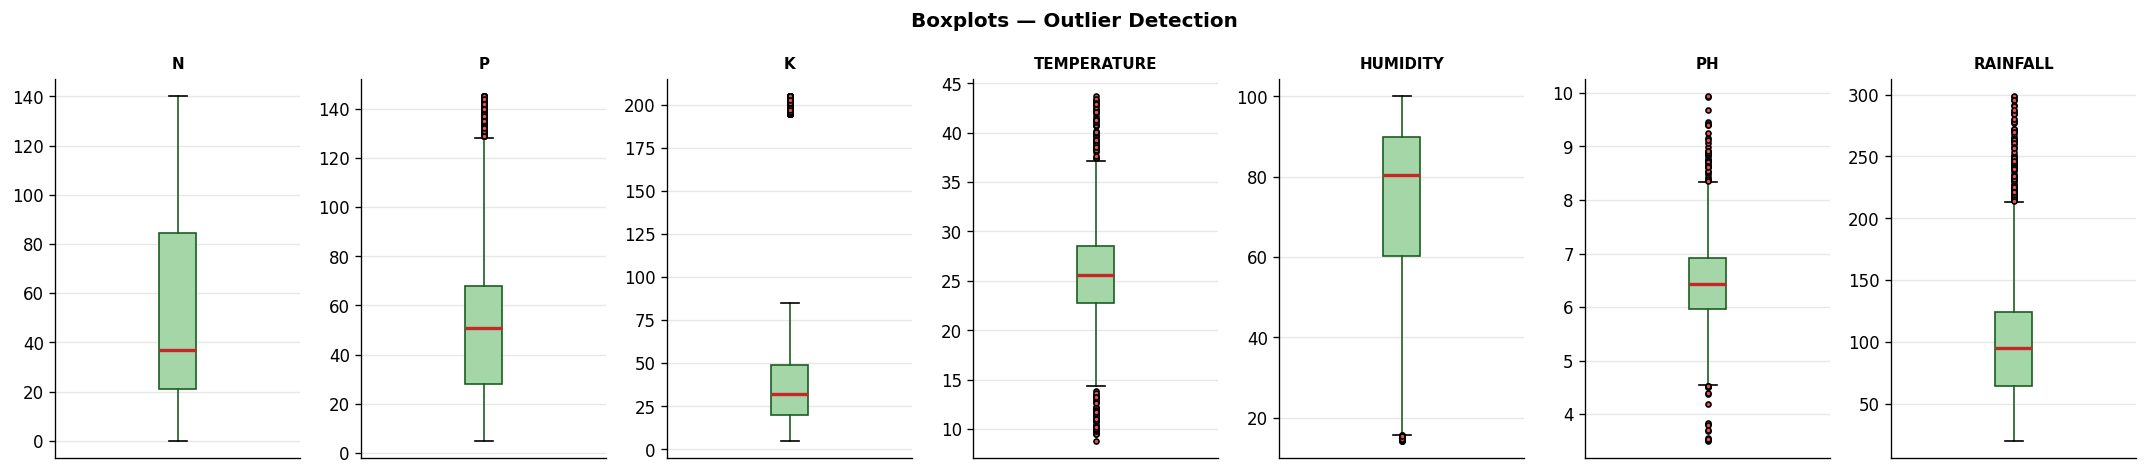

Outlier counts per feature (IQR method):
  n              : 0 outliers (0.0%)
  p              : 138 outliers (6.3%)
  k              : 200 outliers (9.1%)
  temperature    : 86 outliers (3.9%)
  humidity       : 30 outliers (1.4%)
  ph             : 57 outliers (2.6%)
  rainfall       : 100 outliers (4.5%)


In [10]:
fig, axes = plt.subplots(1, 7, figsize=(18, 4))
for i, feat in enumerate(FEATURES):
    axes[i].boxplot(df[feat], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#A5D6A7', color='#1B5E20'),
                    medianprops=dict(color='#C62828', linewidth=2),
                    whiskerprops=dict(color='#1B5E20'),
                    flierprops=dict(marker='o', markerfacecolor='#EF5350', markersize=3))
    axes[i].set_title(feat.upper(), fontsize=9, fontweight='bold')
    axes[i].set_xticks([])

fig.suptitle('Boxplots — Outlier Detection', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/phase1_boxplots.png', bbox_inches='tight')
plt.show()

# Count outliers
print('Outlier counts per feature (IQR method):')
for feat in FEATURES:
    Q1, Q3 = df[feat].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f'  {feat:15s}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

## 1.7  Feature vs Crop (Top crops)

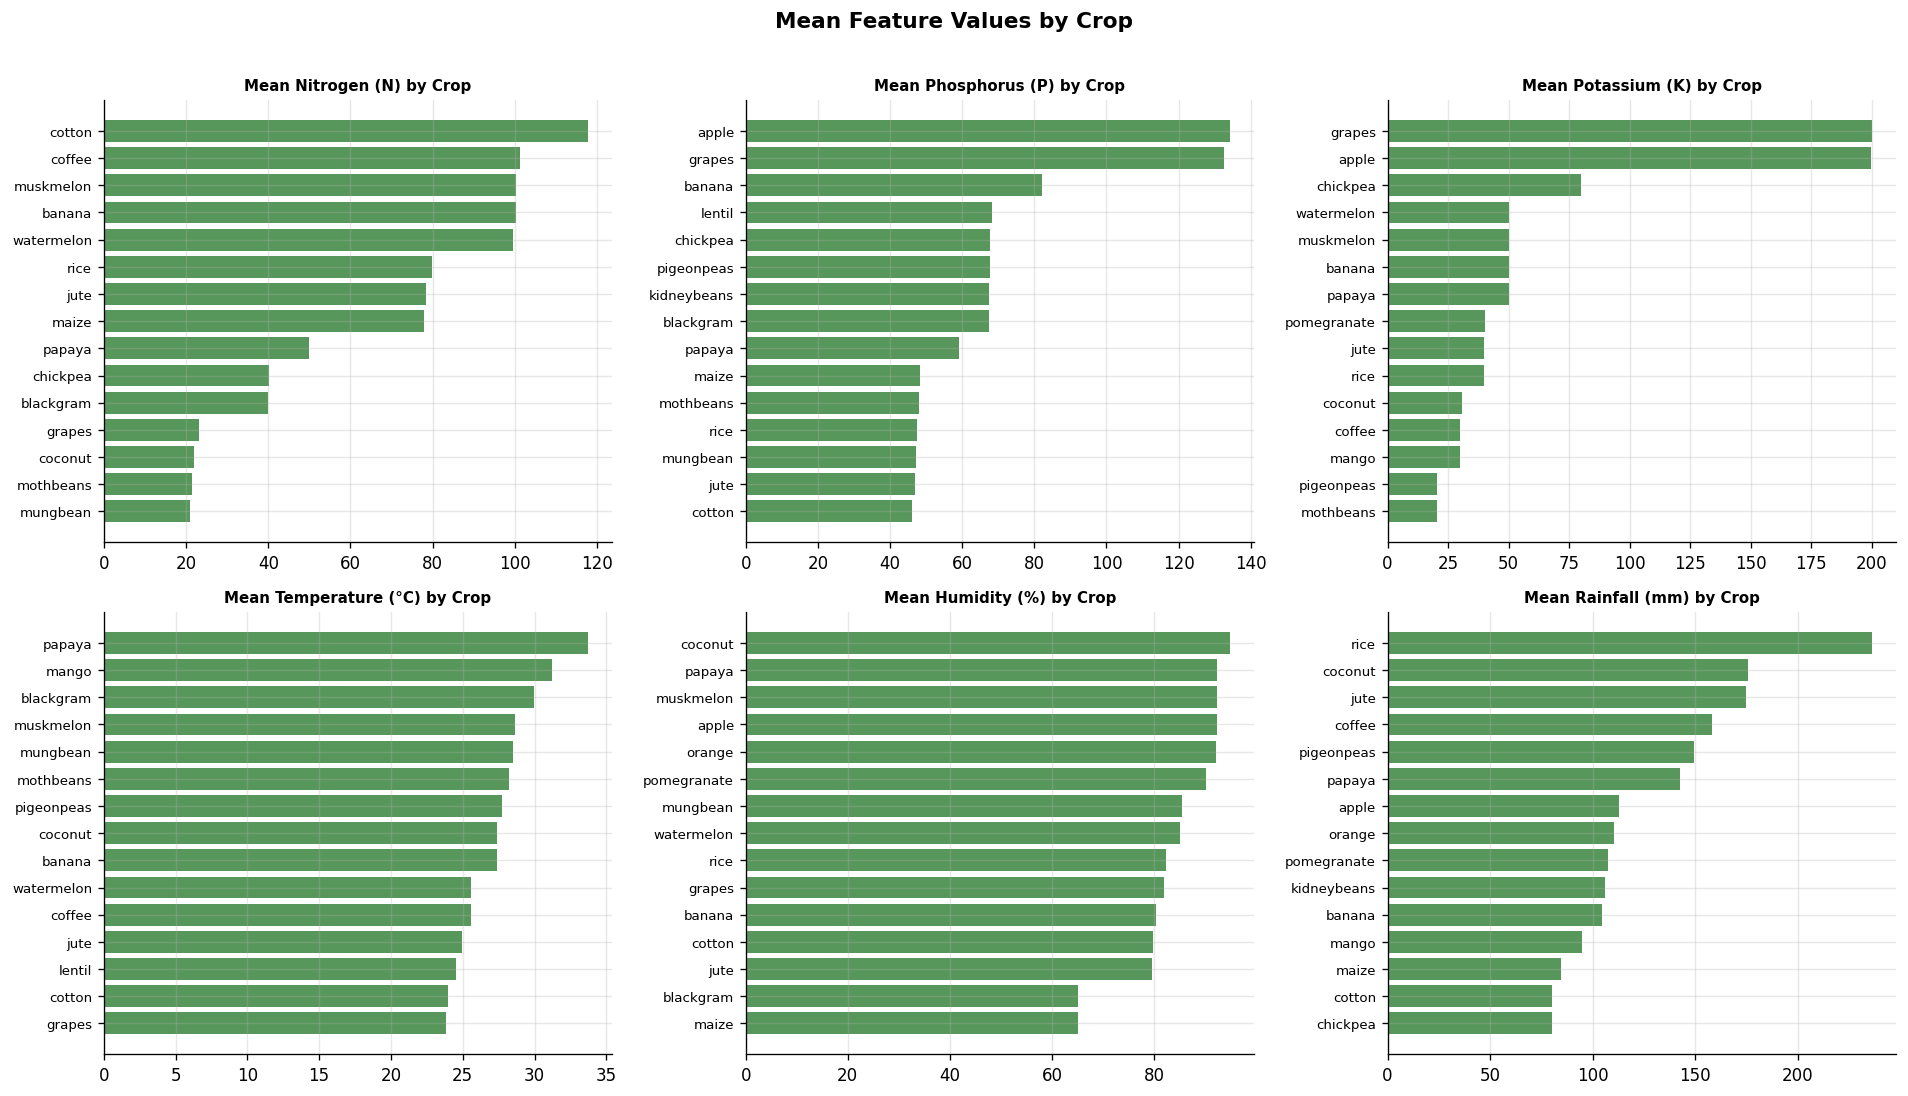

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
plot_feats = ['n', 'p', 'k', 'temperature', 'humidity', 'rainfall']

for i, feat in enumerate(plot_feats):
    means = df.groupby('label')[feat].mean().sort_values(ascending=False).head(15)
    axes[i].barh(means.index[::-1], means.values[::-1],
                 color='#2E7D32', alpha=0.8)
    axes[i].set_title(f'Mean {labels_map[feat]} by Crop', fontweight='bold', fontsize=9)
    axes[i].tick_params(axis='y', labelsize=8)

fig.suptitle('Mean Feature Values by Crop', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase1_feature_by_crop.png', bbox_inches='tight')
plt.show()

## 1.8  Save Processed Data

In [12]:
import pickle

processed = {
    'df':       df,
    'features': FEATURES,
    'n_classes': df['label'].nunique(),
    'class_names': df['label'].unique().tolist(),
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(processed, f)

print('processed_data.pkl saved.')
print(f'Records: {len(df)}')
print(f'Features: {FEATURES}')
print(f'Crops: {df["label"].nunique()}')

processed_data.pkl saved.
Records: 2200
Features: ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
Crops: 22
